In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import ast
import pandas as pd

splits = [92, 183, 366, 732, 1464]
all_results = {}

for split in splits:
    all_results[split] = {}
    project_file_path = f'./project_{split}.csv'
    project_data = pd.read_csv(project_file_path)
    
    # Convert the 'summary' column from string representation of dictionaries to actual dictionaries
    project_data['summary'] = project_data['summary'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('{') else {})
    
    # Extract 'eval/mIoU_ema' values from the summary dictionaries, defaulting to NaN if not found
    project_data['eval/mIoU_ema'] = project_data['summary'].apply(lambda x: x.get('eval/mIoU_ema', None))
    
    # Drop rows where 'eval/mIoU_ema' is missing
    project_data = project_data.dropna(subset=['eval/mIoU_ema'])
    
    # Convert 'eval/mIoU_ema' to numeric type for averaging
    project_data['eval/mIoU_ema'] = pd.to_numeric(project_data['eval/mIoU_ema'])
    
    # Group by the 'name' column and average the 'eval/mIoU_ema' values
    average_mIoU_ema = project_data.groupby('name')['eval/mIoU_ema'].mean().reset_index()
    
    # Sort the results in descending order
    sorted_average_mIoU_ema = average_mIoU_ema.sort_values(by='eval/mIoU_ema', ascending=False).reset_index(drop=True)
    
    # Split the sorted DataFrame into three groups based on the size mentioned in the name: 'small', 'base', and 'large'
    all_results[split]["small"] = sorted_average_mIoU_ema[sorted_average_mIoU_ema['name'].str.contains('small', case=False)]
    all_results[split]["base"] = sorted_average_mIoU_ema[sorted_average_mIoU_ema['name'].str.contains('base', case=False)]
    # large_models = sorted_average_mIoU_ema[sorted_average_mIoU_ema['name'].str.contains('large', case=False)]
    
    # Show the separated groups
    # small_models, base_models



In [39]:
small_baselines = []
base_baselines = []

small_fa = []
base_fa = []

small_fa_norm = []
base_fa_norm = []

small_fa_gradient = []
base_fa_gradient = []

small_norm = []
base_norm = []

small_norm_gradient = []
base_norm_gradient = []

small_gradient = []
base_gradient = []

small_fa_norm_gradient = []
base_fa_norm_gradient = []


for split in all_results.keys():
    df_small = all_results[split]['small']
    df_base = all_results[split]['base']
    
    small_value = df_small.loc[df_small['name'] == 'unimatch_v2_wandb_wo_FA_dino_small', 'eval/mIoU_ema'].values[0]
    small_baselines.append(small_value)

    base_value = df_base.loc[df_base['name'] == 'unimatch_v2_wandb_wo_FA_dino_base', 'eval/mIoU_ema'].values[0]
    base_baselines.append(base_value)

    ##############################3
    
    small_value = df_small.loc[df_small['name'] == 'unimatch_v2_wandb_dino_small', 'eval/mIoU_ema'].values[0]
    small_fa.append(small_value)

    base_value = df_base.loc[df_base['name'] == 'unimatch_v2_wandb_dino_base', 'eval/mIoU_ema'].values[0]
    base_fa.append(base_value)

    ##############################3
    
    small_value = df_small.loc[df_small['name'] == 'unimatch_v2_wandb_normloss_dino_small', 'eval/mIoU_ema'].values[0]
    small_fa_norm.append(small_value)

    base_value = df_base.loc[df_base['name'] == 'unimatch_v2_wandb_normloss_dino_base', 'eval/mIoU_ema'].values[0]
    base_fa_norm.append(base_value)

    ##############################3
    
    small_value = df_small.loc[df_small['name'] == 'unimatch_v2_wandb_gradient_dino_small', 'eval/mIoU_ema'].values[0]
    small_fa_gradient.append(small_value)

    base_value = df_base.loc[df_base['name'] == 'unimatch_v2_wandb_gradient_dino_base', 'eval/mIoU_ema'].values[0]
    base_fa_gradient.append(base_value)

    ##############################3
    
    small_value = df_small.loc[df_small['name'] == 'unimatch_v2_wandb_wo_FA_normloss_dino_small', 'eval/mIoU_ema'].values[0]
    small_norm.append(small_value)

    base_value = df_base.loc[df_base['name'] == 'unimatch_v2_wandb_wo_FA_normloss_dino_base', 'eval/mIoU_ema'].values[0]
    base_norm.append(base_value)

    ##############################3
    
    small_value = df_small.loc[df_small['name'] == 'unimatch_v2_wandb_wo_FA_normloss_gradient_dino_small', 'eval/mIoU_ema'].values[0]
    small_norm_gradient.append(small_value)

    base_value = df_base.loc[df_base['name'] == 'unimatch_v2_wandb_wo_FA_normloss_gradient_dino_base', 'eval/mIoU_ema'].values[0]
    base_norm_gradient.append(base_value)

    ##############################3
    
    small_value = df_small.loc[df_small['name'] == 'unimatch_v2_wandb_wo_FA_gradient_dino_small', 'eval/mIoU_ema'].values[0]
    small_gradient.append(small_value)

    base_value = df_base.loc[df_base['name'] == 'unimatch_v2_wandb_wo_FA_gradient_dino_base', 'eval/mIoU_ema'].values[0]
    base_gradient.append(base_value)

     ##############################3
    
    small_value = df_small.loc[df_small['name'] == 'unimatch_v2_wandb_normloss_gradient_dino_small', 'eval/mIoU_ema'].values[0]
    small_fa_norm_gradient.append(small_value)

    base_value = df_base.loc[df_base['name'] == 'unimatch_v2_wandb_normloss_gradient_dino_base', 'eval/mIoU_ema'].values[0]
    base_fa_norm_gradient.append(base_value)
    # print(value)


[np.float64(79.7157831152324), np.float64(84.26067943516284), np.float64(84.50372367839422), np.float64(85.73706586579517), np.float64(86.90218234703403)]


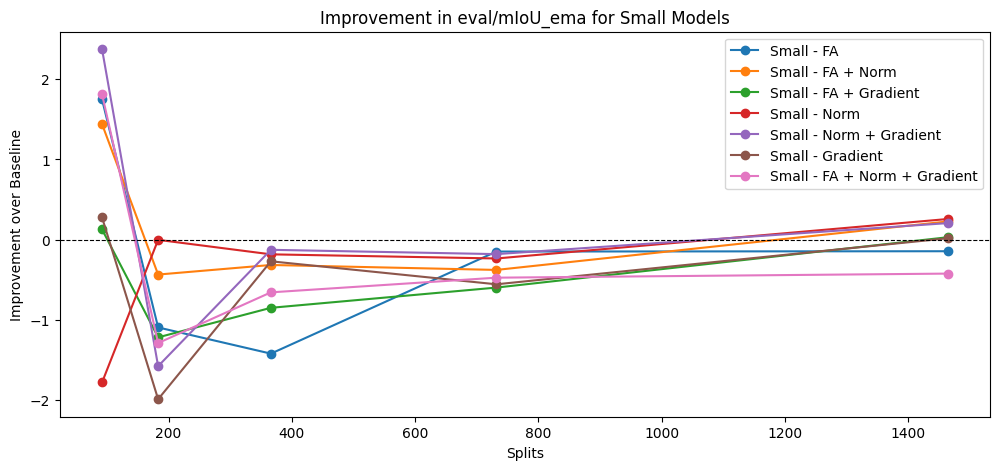

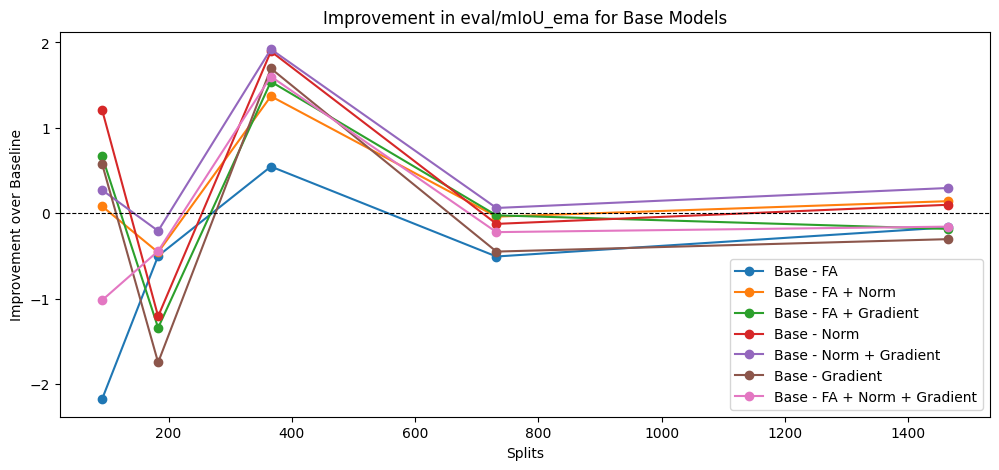

In [45]:
# Define splits
splits = [92, 183, 366, 732, 1464]

# Ensure that data arrays are correctly structured (assuming they have been re-populated)
if len(small_baselines) == len(splits) and len(base_baselines) == len(splits):
    # Compute improvement over baseline for each split for small models
    small_improvements = [
        np.array(small_fa) - np.array(small_baselines),
        np.array(small_fa_norm) - np.array(small_baselines),
        np.array(small_fa_gradient) - np.array(small_baselines),
        np.array(small_norm) - np.array(small_baselines),
        np.array(small_norm_gradient) - np.array(small_baselines),
        np.array(small_gradient) - np.array(small_baselines),
        np.array(small_fa_norm_gradient) - np.array(small_baselines),
    ]

    # Compute improvement over baseline for each split for base models
    base_improvements = [
        np.array(base_fa) - np.array(base_baselines),
        np.array(base_fa_norm) - np.array(base_baselines),
        np.array(base_fa_gradient) - np.array(base_baselines),
        np.array(base_norm) - np.array(base_baselines),
        np.array(base_norm_gradient) - np.array(base_baselines),
        np.array(base_gradient) - np.array(base_baselines),
        np.array(base_fa_norm_gradient) - np.array(base_baselines),
    ]

    # Plot improvements for small models
    plt.figure(figsize=(12, 5))
    for i, method in enumerate(methods):
        plt.plot(splits, small_improvements[i], marker='o', label=f"Small - {method}")

    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # Baseline reference line
    plt.xlabel("Splits")
    plt.ylabel("Improvement over Baseline")
    plt.title("Improvement in eval/mIoU_ema for Small Models")
    plt.legend()
    # plt.xscale("log")  # Log scale to represent splits better
    plt.show()

    # Plot improvements for base models
    plt.figure(figsize=(12, 5))
    for i, method in enumerate(methods):
        plt.plot(splits, base_improvements[i], marker='o', label=f"Base - {method}")

    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # Baseline reference line
    plt.xlabel("Splits")
    plt.ylabel("Improvement over Baseline")
    plt.title("Improvement in eval/mIoU_ema for Base Models")
    plt.legend()
    # plt.xscale("log")  # Log scale to represent splits better
    plt.show()
else:
    print("Error: Ensure small_baselines and base_baselines are correctly populated before plotting.")
